# GreenPEFT Surrogate Dataset — Research Notebook

**Purpose:** Exploratory data analysis, data-quality assessment, statistical comparison of PEFT methods, and baseline cost modelling on the GreenPEFT surrogate dataset.

**Citation:**
```bibtex
@misc{ashraful_islam_tanzil_2026,
  title={greenpeft-surrogate-data},
  url={https://www.kaggle.com/dsv/20178095},
  DOI={10.34740/KAGGLE/DSV/20178095},
  publisher={Kaggle},
  author={Ashraful Islam Tanzil},
  year={2026}
}
```

---
> **Read this before interpreting any number below.**
>
> The 82 `surrogate_train` rows are **not** 82 independent runs. They are **41 configurations measured twice**,
> paired by `config_id`. The second (`remeasured`) pass recorded a flat ~10 W implied power — the NVML idle
> floor rather than loaded training power — and is flagged `energy_measurement_valid == 0`.
>
> Pooling the two passes understates mean energy by ~42% and doubles every sample count. Section 4b therefore
> collapses the pairs into one canonical row per configuration **before** any statistic is computed. Every EDA,
> comparison and modelling section below operates on that canonical frame (`runs`, 41 rows), never on the raw frame.

---
**Notebook outline**
1. Setup & imports
2. Load data
3. Schema & data dictionary
4. Data-quality audit (`is_empirical`, `analysis_role`, `data_quality_flag`)

    4b. **Canonicalisation — collapse measurement passes, apply the energy-validity filter**
5. Exploratory data analysis (methods, scales, metrics)
6. Comparative analysis: PEFT vs full fine-tuning
7. Efficiency frontiers (accuracy vs energy, accuracy vs memory)
8. Pre-run cost surrogate (accuracy / VRAM / energy / runtime)
9. Summary & next steps

In [1]:
# ============================================================
# 1. SETUP & IMPORTS
# ============================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('pandas', pd.__version__)
print('numpy ', np.__version__)

pandas 3.0.6
numpy  2.0.2


In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================
import os, glob

CSV_NAME = "greenpeft_ml_ready_dataset.csv"

# Kaggle location first, then local checkouts, then a recursive sweep.
CANDIDATES = [
    f"/kaggle/input/datasets/ashrafulislamtanzil/greenpeft-surrogate-data/{CSV_NAME}",
    f"new update works/{CSV_NAME}",
    f"../new update works/{CSV_NAME}",
    CSV_NAME,
]

DATA_PATH = next((c for c in CANDIDATES if os.path.exists(c)), None)

if DATA_PATH is None:
    for pat in (f"/kaggle/input/**/{CSV_NAME}", f"**/{CSV_NAME}"):
        matches = glob.glob(pat, recursive=True)
        if matches:
            DATA_PATH = matches[0]
            break

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not find {CSV_NAME}. On Kaggle, re-attach the 'greenpeft-surrogate-data' "
        "dataset from the right sidebar; locally, run this notebook from the repository root."
    )

print("Loading:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head(3)

Loading: new update works/greenpeft_ml_ready_dataset.csv
Shape: (477, 46)


,run_id,method,backbone,family,params_b,rank,quant_bits,is_adapter_method,gpu_total_gb,status,fits,trainable_param_pct,accuracy,peak_gpu_memory_gb,energy_kwh,carbon_kgco2eq,wall_clock_seconds,carbon_derived_kg,log_params_b,params_x_bits,log_params_x_bits,weight_bytes_gb,trainable_frac,trainable_params_b,optimizer_state_gb,gradient_gb,memory_proxy_gb,vram_pressure,is_quantized,adapter_capacity,log1p_rank,is_full_finetune,energy_per_acc_point,vram_efficiency,throughput_proxy,has_adapter_config,gpu_budget_known,is_seed_outlier,config_id,measurement_pass,energy_measurement_valid,analysis_role,split_reason,data_source,is_empirical,data_quality_flag
0,full_ft_tiny_classification_seed13,full_ft,tiny,qwen,0.5,0.0,32,0.0,15.6,ok,1,1.0,0.9117,11.462,0.002394,0.001556,132.28,0.001556,-0.30103,16.0,1.20412,2.0,0.01,0.005,0.04,0.02,2.06,0.132051,0,0.0,0.0,1,0.002626,0.079541,0.007560,1,1,0,full_ft_tiny_classification_seed13,original,1,surrogate_train,measured single-GPU PEFT fine-tuning run,greenpeft_kaggle_t4_benchmark,1,measured_single_gpu_peft_finetuning_run
1,full_ft_tiny_classification_seed2024,full_ft,tiny,qwen,0.5,0.0,32,0.0,15.6,ok,1,1.0,0.8991,11.439,0.002409,0.001566,132.95,0.001566,-0.30103,16.0,1.20412,2.0,0.01,0.005,0.04,0.02,2.06,0.132051,0,0.0,0.0,1,0.002680,0.078600,0.007522,1,1,0,full_ft_tiny_classification_seed2024,original,1,surrogate_train,measured single-GPU PEFT fine-tuning run,greenpeft_kaggle_t4_benchmark,1,measured_single_gpu_peft_finetuning_run
2,full_ft_tiny_classification_seed42,full_ft,tiny,qwen,0.5,0.0,32,0.0,15.6,ok,1,1.0,0.9048,11.414,0.002380,0.001547,131.62,0.001547,-0.30103,16.0,1.20412,2.0,0.01,0.005,0.04,0.02,2.06,0.132051,0,0.0,0.0,1,0.002630,0.079271,0.007598,1,1,0,full_ft_tiny_classification_seed42,original,1,surrogate_train,measured single-GPU PEFT fine-tuning run,greenpeft_kaggle_t4_benchmark,1,measured_single_gpu_peft_finetuning_run


In [3]:
# ============================================================
# 3. SCHEMA & DATA DICTIONARY
# ============================================================
schema = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_nonnull': df.notna().sum(),
    'n_null': df.isna().sum(),
    'pct_null': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(dropna=True)
})
schema

,dtype,n_nonnull,n_null,pct_null,n_unique
run_id,str,477,0,0.00,477
method,str,477,0,0.00,7
backbone,str,477,0,0.00,6
family,str,477,0,0.00,6
params_b,float64,477,0,0.00,47
rank,float64,477,0,0.00,2
quant_bits,int64,477,0,0.00,3
is_adapter_method,float64,477,0,0.00,2
gpu_total_gb,float64,82,395,82.81,1
status,str,477,0,0.00,1


### Key columns

| Column | Meaning |
|---|---|
| `run_id` | Unique **row** identifier — one per measurement pass |
| `config_id` | Unique **configuration** identifier — the two passes of a run share it |
| `measurement_pass` | `original` / `remeasured` for benchmark rows, `single` otherwise |
| `energy_measurement_valid` | 1 if this row's energy telemetry is trustworthy, else 0 |
| `method` | PEFT / training method (`full_ft`, `lisa`, `lora`, `lora_fa`, `qlora`, `none_inference_only`, `pretrain_full_scratch`) |
| `backbone` | Size bucket (`tiny`, `small`, `medium`, `large`, `xlarge`, `huge`) |
| `family` | Model family (`qwen`, `llama`, `other`, `mistral`, `gemini`, `falcon`, `gemma`) |
| `params_b` | Parameter count in billions |
| `rank`, `quant_bits` | LoRA rank and quantisation width |
| `is_adapter_method` | 1 if LoRA-style adapter, else 0 |
| `accuracy` | Downstream task accuracy |
| `peak_gpu_memory_gb` | Peak GPU memory |
| `energy_kwh` | Training energy — **only meaningful where `energy_measurement_valid == 1`** |
| `carbon_kgco2eq` | Carbon footprint — **derived**, exactly `energy_kwh * 0.65` |
| `wall_clock_seconds` | Training time |
| `analysis_role` | `surrogate_train`, `scale_reference`, `context_only` |
| `is_empirical` | 1 if measured, 0 if derived context |
| `data_quality_flag` | Free-text provenance note |

**Two filters are mandatory before any comparison:**

1. **Filter by `analysis_role`.** The dataset mixes three physical regimes — PEFT fine-tuning, an
   inference-only leaderboard, and pretraining-from-scratch. Their energy columns differ by orders of
   magnitude and are not comparable.
2. **Collapse by `config_id` and respect `energy_measurement_valid`.** See section 4b.

In [4]:
# ============================================================
# 4. DATA-QUALITY AUDIT
# ============================================================
print('analysis_role counts:')
print(df['analysis_role'].value_counts(), '\n')

print('is_empirical counts:')
print(df['is_empirical'].value_counts(), '\n')

print('data_quality_flag counts:')
print(df['data_quality_flag'].value_counts(), '\n')

print('measurement_pass counts:')
print(df['measurement_pass'].value_counts(), '\n')

print('energy_measurement_valid counts:')
print(df['energy_measurement_valid'].value_counts())

analysis_role counts:
analysis_role
scale_reference    369
surrogate_train     82
context_only        26
Name: count, dtype: int64 

is_empirical counts:
is_empirical
1    467
0     10
Name: count, dtype: int64 

data_quality_flag counts:
data_quality_flag
inference_only_no_finetuning_method_applied                                                                            369
measured_single_gpu_peft_finetuning_run                                                                                 82
PRETRAINING_FROM_SCRATCH_NOT_FINETUNING -- energy/time are 9+ orders of magnitude larger than single-GPU PEFT runs.     26
Name: count, dtype: int64 

measurement_pass counts:
measurement_pass
single        395
original       41
remeasured     41
Name: count, dtype: int64 

energy_measurement_valid counts:
energy_measurement_valid
0    420
1     57
Name: count, dtype: int64


In [5]:
# Split the dataset by provenance so downstream analyses stay clean.
peft_runs = df[df['analysis_role'] == 'surrogate_train'].copy()
scale_ref = df[df['analysis_role'] == 'scale_reference'].copy()
context    = df[df['analysis_role'] == 'context_only'].copy()

print(f'surrogate_train : {peft_runs.shape}')
print(f'scale_reference : {scale_ref.shape}')
print(f'context_only    : {context.shape}')

# Focus of this notebook: empirical PEFT runs
peft_runs = peft_runs[peft_runs['is_empirical'] == 1].reset_index(drop=True)
print('\nEmpirical PEFT runs only:', peft_runs.shape)

surrogate_train : (82, 46)
scale_reference : (369, 46)
context_only    : (26, 46)

Empirical PEFT runs only: (82, 46)


## 4b. Canonicalisation — collapse measurement passes, apply the energy-validity filter

The benchmark measured each configuration **twice**. Treating those passes as independent rows is the single
largest source of error in a naive analysis of this dataset, so it is resolved once, here, and the raw frame is
never analysed again.

Collapse rules, each backed by an assertion in the cell below rather than an assumption:

| Field | Rule | Why |
|---|---|---|
| `accuracy` | take either pass | Identical across passes for all 41 configs (asserted) — accuracy was not re-evaluated, only resource telemetry was |
| `peak_gpu_memory_gb` | mean of both passes | Both are genuine allocator high-water marks; the spread is real run-to-run variance, retained as `*_pass_sd` |
| `wall_clock_seconds` | mean of both passes | Same reasoning |
| `energy_kwh` | **valid pass only** | The `remeasured` pass is an NVML idle floor, not loaded training power |
| `carbon_kgco2eq` | recomputed as `energy_kwh * 0.65` | Carbon is derived, never independently measured |

The result is `runs`: **41 rows, one per (method, backbone, seed)**. Sample counts in every table below are
therefore true seed counts, and `config_base` (method + backbone, seed stripped) becomes available as the
correct cross-validation grouping key.

In [6]:
# ============================================================
# 4b. CANONICALISATION
# ============================================================
CARBON_FACTOR = 0.65   # kgCO2eq per kWh -- project assumption, see DATA_METHODOLOGY.md

# Outcome columns, and reporting ratios derived from them. These are either collapsed
# with an explicit rule below or excluded entirely; they must never be carried forward
# as if they were per-configuration constants.
OUTCOME_COLS = [
    'accuracy', 'peak_gpu_memory_gb', 'wall_clock_seconds',
    'energy_kwh', 'carbon_kgco2eq', 'carbon_derived_kg',
    'energy_per_acc_point', 'vram_efficiency', 'throughput_proxy',
]
PASS_COLS = ['run_id', 'measurement_pass', 'energy_measurement_valid']
GROUP_KEY = 'config_id'   # becomes the index of the collapsed frame, not a selected column

# `peft_runs` stays as the raw, uncollapsed frame for auditability. Nothing below analyses it.
raw = peft_runs
g = raw.groupby('config_id')

# --- Verify the collapse preconditions instead of assuming them ------------------
assert set(g.size().unique()) == {2}, 'Expected exactly 2 measurement passes per config_id'
assert set(g['accuracy'].nunique().unique()) == {1}, \
    'Accuracy differs between passes; a mean would be required instead of first()'
assert set(g['energy_measurement_valid'].sum().unique()) == {1}, \
    'Expected exactly 1 valid-energy pass per config_id'
assert np.allclose(raw['carbon_kgco2eq'] / raw['energy_kwh'], CARBON_FACTOR, atol=1e-4), \
    'carbon_kgco2eq is not exactly energy_kwh * 0.65'
print('Collapse preconditions verified: '
      f'{raw["config_id"].nunique()} configs x 2 passes = {len(raw)} rows')

# --- Static (pre-run) columns: provably constant within a config_id --------------
EXCLUDED = OUTCOME_COLS + PASS_COLS + [GROUP_KEY]
static_cols = [c for c in raw.columns
               if c not in EXCLUDED and g[c].nunique(dropna=False).max() == 1]
varying = [c for c in raw.columns if c not in EXCLUDED and c not in static_cols]
if varying:
    print('Non-outcome columns that vary within a config_id, excluded:', varying)

runs = g[static_cols].first().reset_index()   # config_id returns as a column

# accuracy: identical across passes (asserted above)
runs = runs.merge(g['accuracy'].first().rename('accuracy').reset_index(), on='config_id')

# VRAM / wall-clock: mean of the two passes, retaining the observed spread
for col in ['peak_gpu_memory_gb', 'wall_clock_seconds']:
    stats_ = (g[col].agg(['mean', 'std'])
              .rename(columns={'mean': col, 'std': f'{col}_pass_sd'})
              .reset_index())
    runs = runs.merge(stats_, on='config_id')

# energy: valid telemetry pass only; carbon re-derived from it
valid_energy = raw.loc[raw['energy_measurement_valid'] == 1, ['config_id', 'energy_kwh']]
runs = runs.merge(valid_energy, on='config_id', how='left')
runs['carbon_kgco2eq'] = runs['energy_kwh'] * CARBON_FACTOR

# --- Seed and configuration keys ------------------------------------------------
runs['seed'] = runs['config_id'].str.extract(r'seed(\d+)$')[0].astype('Int64')
# config_base identifies a CONFIGURATION (method + backbone + task) independently of seed.
# This -- not config_id -- is the correct grouping key for cross-validation: config_id
# contains the seed, so grouping on it lets two seeds of one config train while the third tests.
runs['config_base'] = runs['config_id'].str.replace(r'_seed\d+$', '', regex=True)

runs = runs.sort_values(['method', 'backbone', 'seed']).reset_index(drop=True)

print(f'\nCanonical frame `runs`: {runs.shape[0]} configurations x {runs.shape[1]} columns')
print(f'  distinct configurations (method x backbone) : {runs["config_base"].nunique()}')
print(f'  seeds per configuration                    : '
      f'{sorted(runs.groupby("config_base").size().unique())}')
print(f'  energy_kwh non-null                        : '
      f'{runs["energy_kwh"].notna().sum()}/{len(runs)}')

# --- Quantify the error this fixes ----------------------------------------------
cmp = pd.DataFrame({
    'pooled_both_passes': raw.groupby('method')['energy_kwh'].mean(),
    'canonical_valid_only': runs.groupby('method')['energy_kwh'].mean(),
    'n_rows_pooled': raw.groupby('method').size(),
    'n_configs_canonical': runs.groupby('method').size(),
})
cmp['pooled_understates_by_pct'] = (
    (1 - cmp['pooled_both_passes'] / cmp['canonical_valid_only']) * 100)
print('\nEffect of pooling the two measurement passes on mean energy_kwh:')
cmp.round(6)

Collapse preconditions verified: 41 configs x 2 passes = 82 rows

Canonical frame `runs`: 41 configurations x 43 columns
  distinct configurations (method x backbone) : 14
  seeds per configuration                    : [np.int64(2), np.int64(3)]
  energy_kwh non-null                        : 41/41

Effect of pooling the two measurement passes on mean energy_kwh:


,pooled_both_passes,canonical_valid_only,n_rows_pooled,n_configs_canonical,pooled_understates_by_pct
method,,,,,
full_ft,0.001388,0.002394,6,3,42.034792
lisa,0.001134,0.001958,18,9,42.081613
lora,0.001002,0.001669,16,8,39.952210
lora_fa,0.001025,0.001729,18,9,40.720830
qlora,0.002100,0.003578,24,12,41.329230


## 5. Exploratory Data Analysis (canonical PEFT configurations)

In [7]:
# Method x backbone coverage, in TRUE seed counts (3 = full seed triple, 0 = never ran / OOM)
ct = pd.crosstab(runs['method'], runs['backbone'])
ct = ct.reindex(columns=[b for b in ['tiny', 'small', 'medium', 'large'] if b in ct.columns])
print('Successful seeds per (method, backbone) -- 3 is a complete triple:')
ct

Successful seeds per (method, backbone) -- 3 is a complete triple:


backbone,tiny,small,medium,large
method,,,,
full_ft,3,0,0,0
lisa,3,3,3,0
lora,3,3,2,0
lora_fa,3,3,3,0
qlora,3,3,3,3


In [8]:
# Summary statistics per method, on canonical configurations
metrics = ['accuracy', 'peak_gpu_memory_gb', 'energy_kwh',
           'wall_clock_seconds', 'carbon_kgco2eq', 'trainable_param_pct']

summary = runs.groupby('method')[metrics].agg(['mean', 'std', 'count'])
print('n = configurations (seeds), not measurement rows. '
      'energy/carbon use the valid telemetry pass only.')
summary.round(6)

n = configurations (seeds), not measurement rows. energy/carbon use the valid telemetry pass only.


accuracy                 peak_gpu_memory_gb                 energy_kwh                 wall_clock_seconds                  carbon_kgco2eq                 trainable_param_pct                
             mean       std count               mean       std count       mean       std count               mean        std count           mean       std count                mean       std count
method                                                                                                                                                                                                
full_ft  0.905200  0.006310     3          11.126500  0.031213     3   0.002394  0.000015     3         135.676667   0.557143     3       0.001556  0.000010     3            1.000000  0.000000     3
lisa     0.915000  0.025356     9          10.399611  4.400258     9   0.001958  0.000558     9         110.570000  29.461662     9       0.001273  0.000363     9            0.836638  0.092342     9
lora     0.934912  0.014849     8           8.156312  3.433578     8   0.001669  0.000408     8         114.818750   9.863352     8       0.001085  0.000265     8            0.003968  0.000710     8
lora_fa  0.927878  0.012265     9           8.294167  3.515393     9   0.001729  0.000373     9         111.764444  10.315615     9       0.001124  0.000243     9            0.001398  0.000269     9
qlora    0.935400  0.015323    12           5.069958  2.131826    12   0.003578  0.001544    12         217.482917  73.041541    12       0.002326  0.001004    12            0.006040  0.001590    12

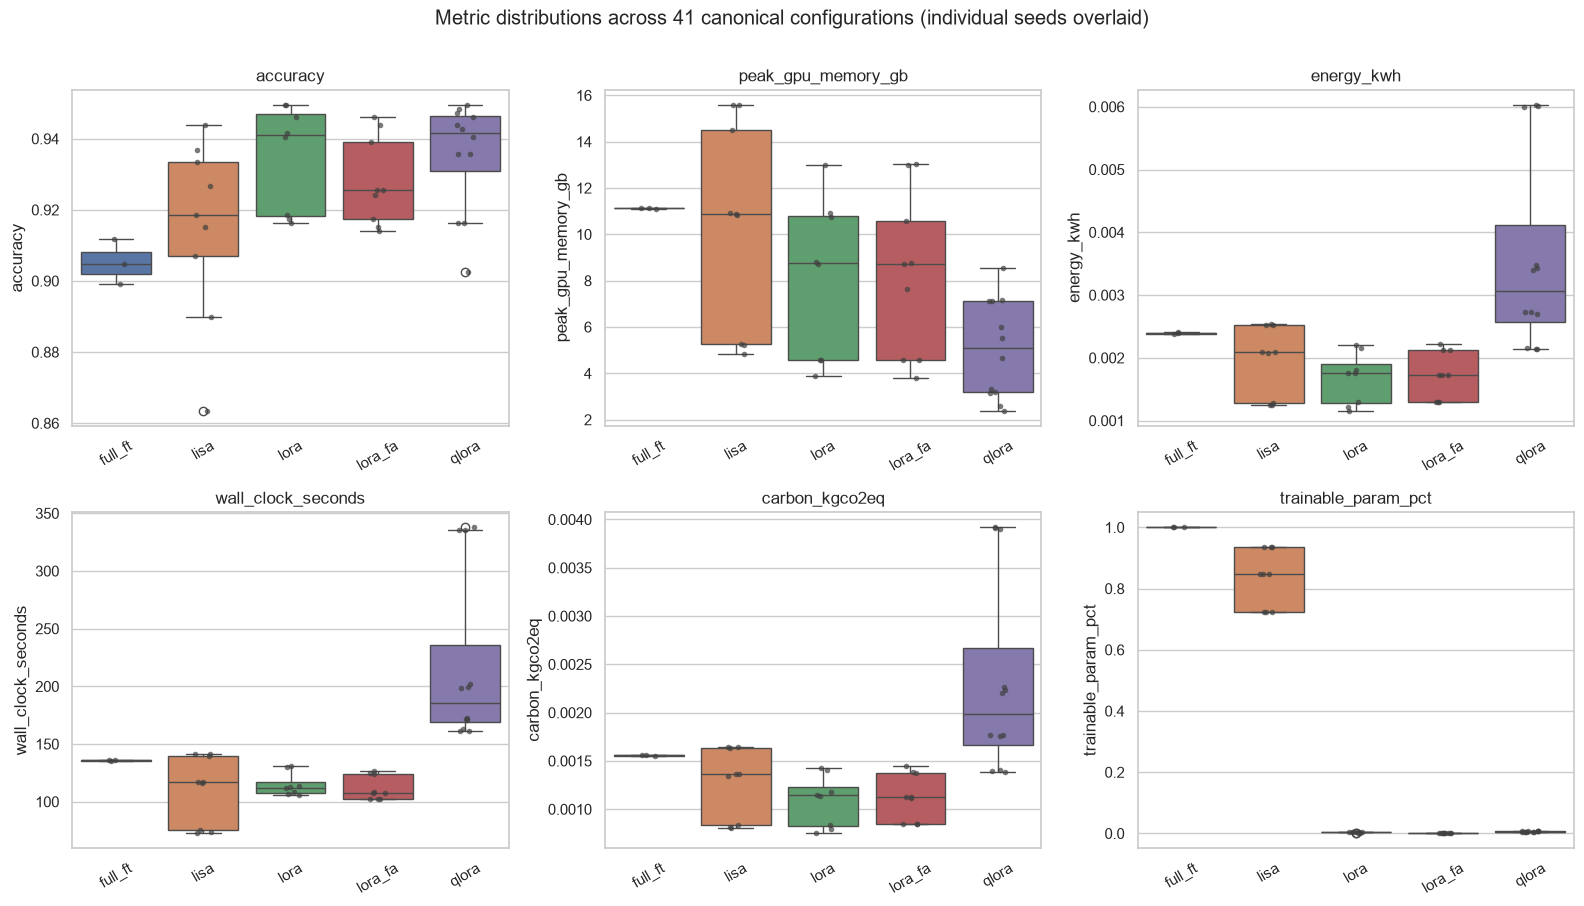

In [9]:
# Distribution plots for the key metrics (canonical configurations)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics_to_plot = ['accuracy', 'peak_gpu_memory_gb', 'energy_kwh',
                   'wall_clock_seconds', 'carbon_kgco2eq', 'trainable_param_pct']

for ax, m in zip(axes.ravel(), metrics_to_plot):
    sns.boxplot(data=runs, x='method', y=m, hue='method', legend=False, ax=ax)
    sns.stripplot(data=runs, x='method', y=m, color='0.25', size=4, alpha=0.7, ax=ax)
    ax.set_title(m)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Metric distributions across 41 canonical configurations '
             '(individual seeds overlaid)', y=1.005)
plt.tight_layout()
plt.show()

Excluded as constant within this benchmark: ['gpu_total_gb', 'fits', 'has_adapter_config', 'gpu_budget_known', 'is_empirical']


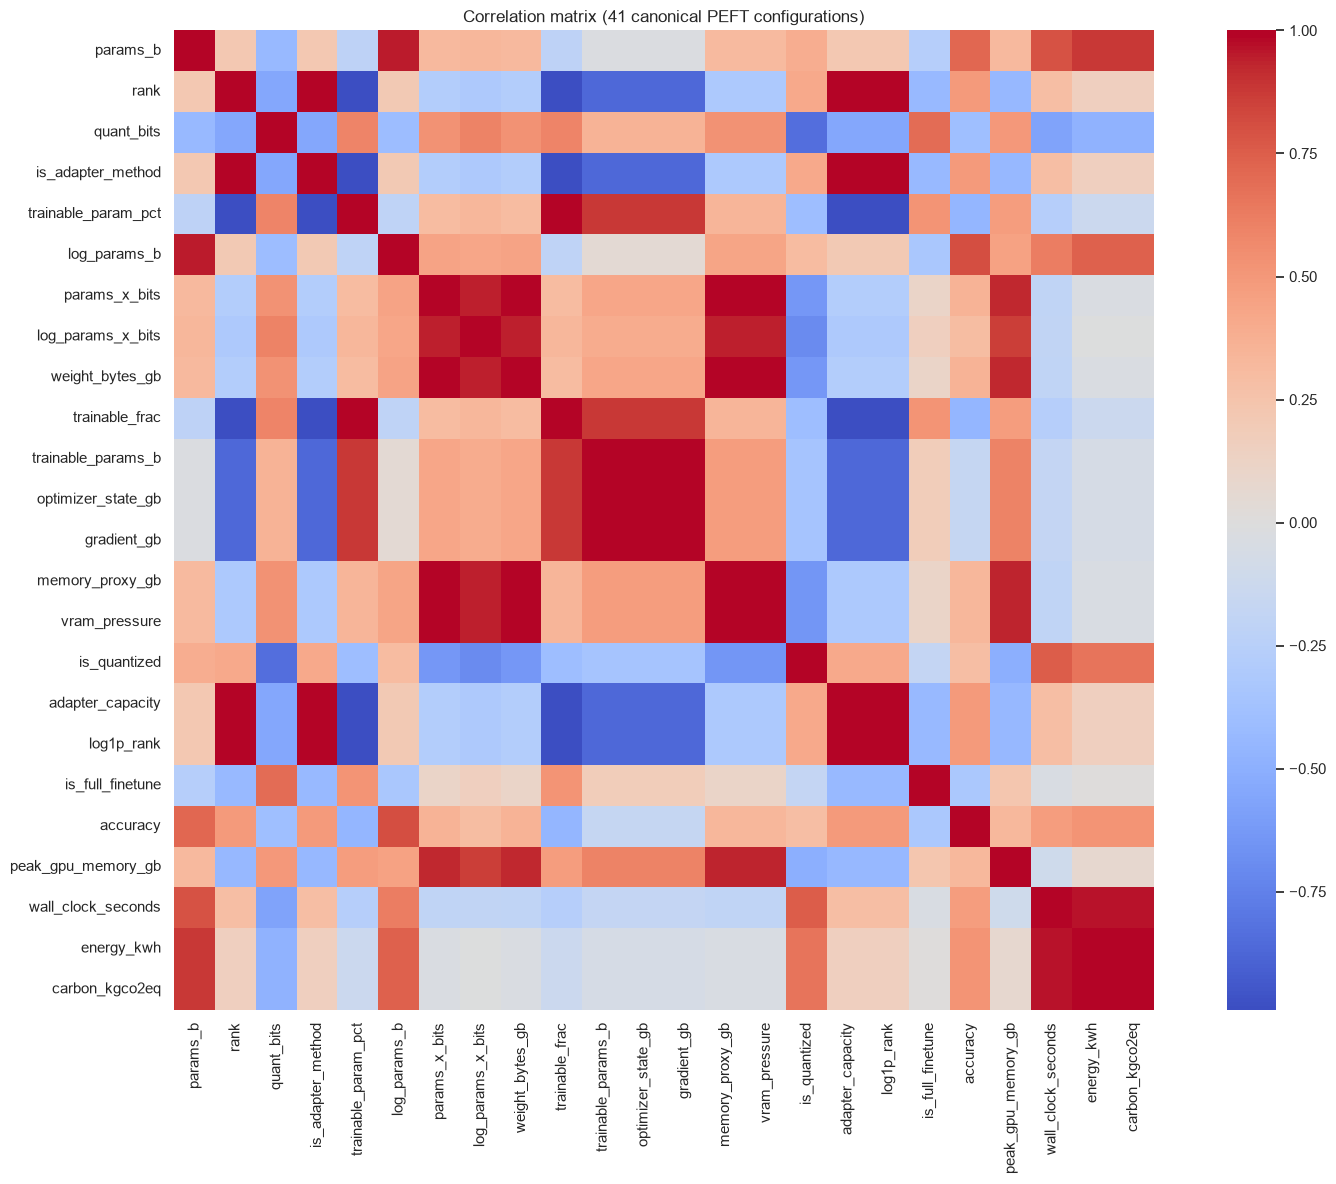


Top correlations with accuracy:
log_params_b          0.8126
params_b              0.7174
energy_kwh            0.5196
carbon_kgco2eq        0.5196
log1p_rank            0.4909
adapter_capacity      0.4909
rank                  0.4909
is_adapter_method     0.4909
wall_clock_seconds    0.4768
params_x_bits         0.3562
Name: accuracy, dtype: float64

Top correlations with energy_kwh:
carbon_kgco2eq        1.0000
wall_clock_seconds    0.9673
params_b              0.8761
log_params_b          0.7418
is_quantized          0.6621
accuracy              0.5196
is_adapter_method     0.1574
adapter_capacity      0.1574
rank                  0.1574
log1p_rank            0.1574
Name: energy_kwh, dtype: float64


In [10]:
# Correlation matrix of numeric columns (canonical configurations)
num_cols = runs.select_dtypes(include=[np.number]).columns.tolist()

# Drop identifiers, constants, and pass-spread bookkeeping -- none carry signal here.
constant_cols = [c for c in num_cols if runs[c].nunique(dropna=True) <= 1]
drop_from_corr = (['is_seed_outlier', 'seed']
                  + [c for c in num_cols if c.endswith('_pass_sd')]
                  + constant_cols)
num_cols = [c for c in num_cols if c not in drop_from_corr]
print('Excluded as constant within this benchmark:', constant_cols)

corr = runs[num_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Correlation matrix (41 canonical PEFT configurations)')
plt.tight_layout()
plt.show()

# Strongest correlations with the two headline outcomes.
# carbon_kgco2eq correlates with energy at exactly 1.0 by construction -- it is derived, not measured.
for target in ['accuracy', 'energy_kwh']:
    print(f'\nTop correlations with {target}:')
    print(corr[target].drop(index=target).sort_values(ascending=False).head(10).round(4))

## 6. Comparative Analysis — PEFT vs Full Fine-Tuning

In [11]:
# Aggregate across seeds for each (method, backbone) configuration.
agg = (runs
       .groupby(['method', 'backbone', 'family', 'params_b'], as_index=False)
       .agg(n_seeds=('config_id', 'count'),
            accuracy_mean=('accuracy', 'mean'),
            accuracy_std=('accuracy', 'std'),
            energy_mean=('energy_kwh', 'mean'),
            energy_std=('energy_kwh', 'std'),
            mem_mean=('peak_gpu_memory_gb', 'mean'),
            time_mean=('wall_clock_seconds', 'mean'))
       .sort_values(['backbone', 'method']))
agg.round(6)

,method,backbone,family,params_b,n_seeds,accuracy_mean,accuracy_std,energy_mean,energy_std,mem_mean,time_mean
10,qlora,large,qwen,3.0,3,0.948367,0.001150,0.006014,0.000015,7.141333,336.086667
1,lisa,medium,qwen,1.5,3,0.938067,0.005248,0.002528,0.000011,15.209833,140.953333
4,lora,medium,qwen,1.5,2,0.947800,0.002404,0.002180,0.000028,11.967500,130.215000
7,lora_fa,medium,qwen,1.5,3,0.943033,0.003513,0.002159,0.000055,12.203667,125.121667
11,qlora,medium,qwen,1.5,3,0.943433,0.002868,0.003436,0.000043,6.417500,200.296667
2,lisa,small,llama,1.1,3,0.920100,0.005895,0.002088,0.000015,10.877333,116.921667
5,lora,small,llama,1.1,3,0.943800,0.004967,0.001774,0.000029,9.428167,106.960000
8,lora_fa,small,llama,1.1,3,0.925100,0.000693,0.001730,0.000007,8.378333,102.358333
12,qlora,small,llama,1.1,3,0.938100,0.003984,0.002717,0.000016,3.958000,161.675000
0,full_ft,tiny,qwen,0.5,3,0.905200,0.006310,0.002394,0.000015,11.126500,135.676667


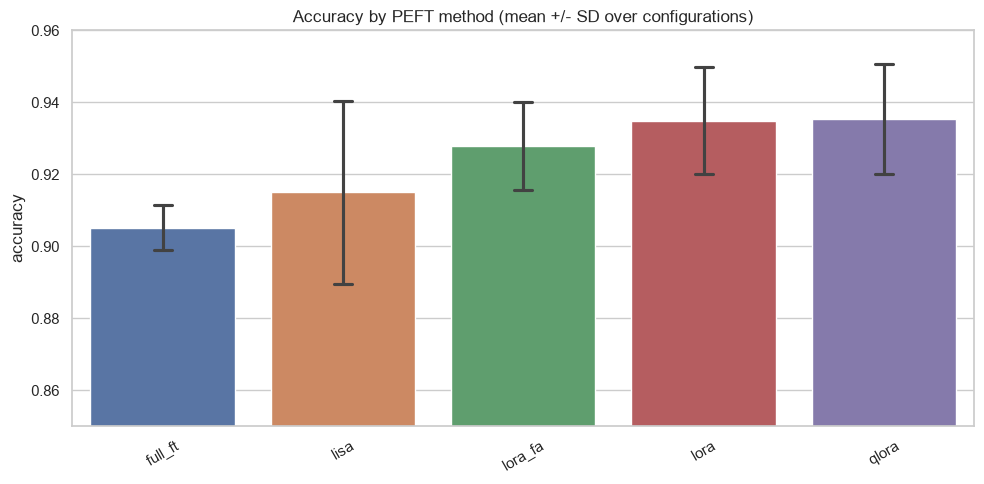

Accuracy spans only 0.086 across all configurations, and each method is measured on a different subset of
backbones (see the coverage table above), so this chart compares methods at unequal scales. It is not a method ranking.


In [12]:
# Bar chart: mean accuracy per method (mean +/- SD across configurations)
plt.figure(figsize=(10, 5))
order = runs.groupby('method')['accuracy'].mean().sort_values().index
# `errorbar=` replaces the `ci=` argument removed in seaborn 0.13.
sns.barplot(data=runs, x='method', y='accuracy', order=order,
            hue='method', hue_order=order, legend=False,
            errorbar='sd', capsize=0.1)
plt.title('Accuracy by PEFT method (mean +/- SD over configurations)')
plt.xlabel('')
plt.xticks(rotation=30)
plt.ylim(0.85, 0.96)
plt.tight_layout()
plt.show()

print('Accuracy spans only '
      f'{runs["accuracy"].max() - runs["accuracy"].min():.3f} across all configurations, and each '
      'method is measured on a different subset of\nbackbones (see the coverage table above), so '
      'this chart compares methods at unequal scales. It is not a method ranking.')

In [13]:
# Paired comparison: each PEFT method vs full fine-tuning on the SAME (backbone, seed).
#
# `runs` holds one row per (method, backbone, seed), so this merge is strictly 1:1 --
# validate='one_to_one' makes that a hard guarantee rather than a hope. On the raw
# two-pass frame the same merge silently produces a 2x2 cross product per seed and
# pairs one method's original telemetry against the other's invalid remeasured pass.
cols = ['backbone', 'seed', 'accuracy', 'energy_kwh',
        'peak_gpu_memory_gb', 'wall_clock_seconds']

ft = runs.loc[runs['method'] == 'full_ft', cols]
rows = []

for m in sorted(runs.loc[runs['method'] != 'full_ft', 'method'].unique()):
    cand = runs.loc[runs['method'] == m, cols]
    pair = cand.merge(ft, on=['backbone', 'seed'], suffixes=('_peft', '_full'),
                      validate='one_to_one')
    if pair.empty:
        continue
    pair.insert(0, 'method', m)
    pair['acc_delta_pp'] = (pair['accuracy_peft'] - pair['accuracy_full']) * 100
    pair['energy_saved_pct'] = (1 - pair['energy_kwh_peft'] / pair['energy_kwh_full']) * 100
    pair['mem_saved_pct'] = (1 - pair['peak_gpu_memory_gb_peft'] / pair['peak_gpu_memory_gb_full']) * 100
    pair['time_saved_pct'] = (1 - pair['wall_clock_seconds_peft'] / pair['wall_clock_seconds_full']) * 100
    rows.append(pair)

if not rows:
    print('No paired (backbone, seed) combinations found against full_ft.')
    print('Backbones with full_ft:', sorted(ft['backbone'].unique()))
else:
    paired = pd.concat(rows, ignore_index=True)
    shown = ['method', 'backbone', 'seed', 'acc_delta_pp',
             'energy_saved_pct', 'mem_saved_pct', 'time_saved_pct']
    print(f'Paired comparisons: {len(paired)} '
          f'(= {paired["method"].nunique()} methods x '
          f'{paired.groupby("method").size().iloc[0]} seeds on the shared backbone)\n')
    print(paired[shown].round(2).to_string(index=False))

    print('\nPer-method mean (positive = PEFT is cheaper / more accurate than full fine-tuning):')
    print(paired.groupby('method')[
        ['acc_delta_pp', 'energy_saved_pct', 'mem_saved_pct', 'time_saved_pct']
    ].mean().round(2).to_string())

    # full_ft only fits on the smallest backbone, so this is the only scale where a
    # paired PEFT-vs-full comparison is possible at all.
    print(f'\nShared backbone(s): {sorted(paired["backbone"].unique())}. '
          'full_ft went OOM at every larger scale under the 15.6 GB budget,\n'
          'so these deltas describe the 0.5B regime only and do not extrapolate.')

Paired comparisons: 12 (= 4 methods x 3 seeds on the shared backbone)

 method backbone  seed  acc_delta_pp  energy_saved_pct  mem_saved_pct  time_saved_pct
   lisa     tiny    13         -4.82             48.04          56.61           46.45
   lisa     tiny    42          0.23             46.22          52.73           44.25
   lisa     tiny  2024         -0.92             47.92          52.83           46.03
   lora     tiny    13          0.46             51.64          65.05           16.72
   lora     tiny    42          1.26             48.90          59.03           17.27
   lora     tiny  2024          1.95             46.38          58.79           17.45
lora_fa     tiny    13          0.57             45.84          66.11           20.07
lora_fa     tiny    42          1.03             45.21          59.02           20.26
lora_fa     tiny  2024          1.49             46.12          58.90           21.28
  qlora     tiny    13         -0.92             10.59          70.12

## 7. Efficiency Frontiers — Accuracy vs Energy vs Memory

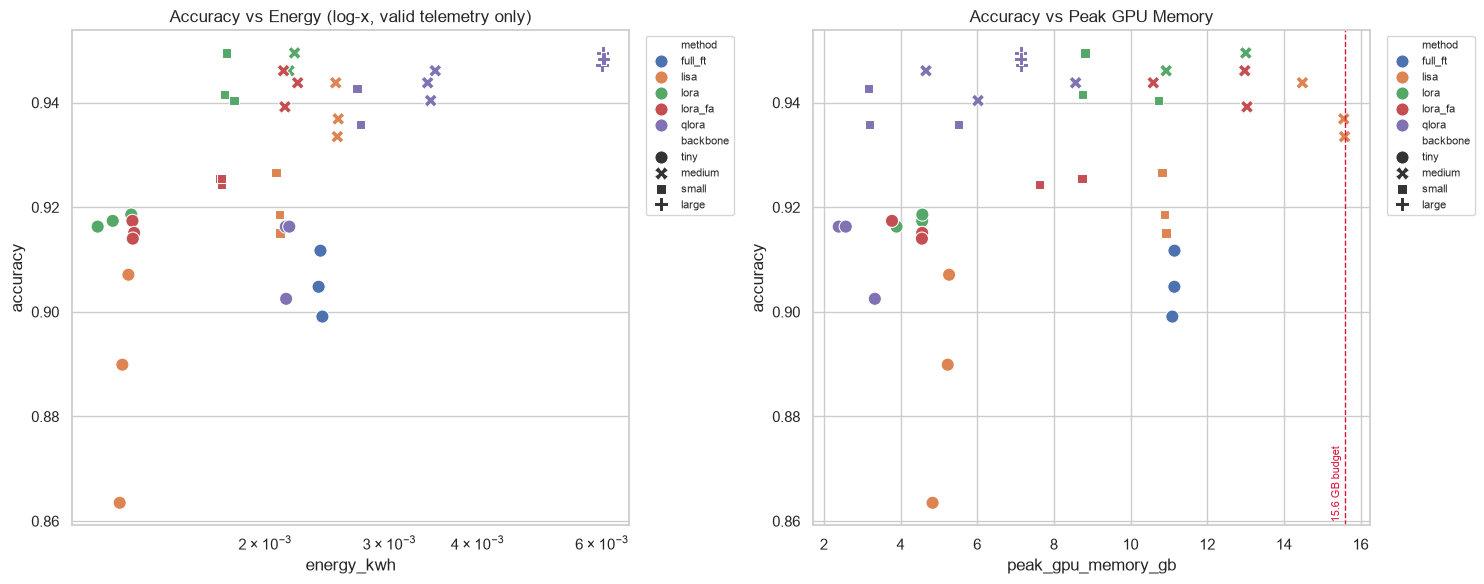

Only feasible configurations appear here: the 19 OOM configurations have no accuracy or energy to plot.
The frontier therefore describes cost GIVEN that a configuration runs, not whether it will run.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy vs energy -- valid telemetry pass only, by construction of `runs`.
sns.scatterplot(data=runs, x='energy_kwh', y='accuracy',
                hue='method', style='backbone', s=90, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Accuracy vs Energy (log-x, valid telemetry only)')
axes[0].set_xlabel('energy_kwh')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# Accuracy vs peak memory, with the VRAM budget that defined feasibility.
sns.scatterplot(data=runs, x='peak_gpu_memory_gb', y='accuracy',
                hue='method', style='backbone', s=90, ax=axes[1])
axes[1].axvline(15.6, color='crimson', ls='--', lw=1)
axes[1].text(15.5, axes[1].get_ylim()[0], ' 15.6 GB budget', color='crimson',
             fontsize=8, rotation=90, va='bottom', ha='right')
axes[1].set_title('Accuracy vs Peak GPU Memory')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

print('Only feasible configurations appear here: the 19 OOM configurations have no accuracy or '
      'energy to plot.\nThe frontier therefore describes cost GIVEN that a configuration runs, '
      'not whether it will run.')

In [15]:
# Energy efficiency: accuracy per kWh. Meaningful only on the valid telemetry pass --
# computed on the pooled two-pass frame, the between-pass gap inflates the SD ~6x and
# the resulting method ranking is an artifact of telemetry, not of the methods.
runs['acc_per_kwh'] = runs['accuracy'] / runs['energy_kwh']

eff = (runs.groupby('method')
       .agg(acc_per_kwh_mean=('acc_per_kwh', 'mean'),
            acc_per_kwh_std=('acc_per_kwh', 'std'),
            n_configs=('config_id', 'count'),
            backbones=('backbone', lambda s: ','.join(sorted(s.unique()))))
       .sort_values('acc_per_kwh_mean', ascending=False))
print('Accuracy per kWh, canonical configurations:')
print(eff.round(2).to_string())

# Within a single backbone the comparison is actually like-for-like.
print('\nSame metric held at one backbone at a time (like-for-like):')
by_bb = (runs.pivot_table(index='method', columns='backbone',
                          values='acc_per_kwh', aggfunc='mean')
         .reindex(columns=[b for b in ['tiny', 'small', 'medium', 'large']
                           if b in runs['backbone'].unique()]))
print(by_bb.round(1).to_string())
print('\nThe pooled column above mixes backbones, and each method covers a different set of them, '
      'so the overall\nordering is confounded by scale. Read the per-backbone table instead.')

Accuracy per kWh, canonical configurations:
         acc_per_kwh_mean  acc_per_kwh_std  n_configs                backbones
method                                                                        
lora               590.36           141.80          8        medium,small,tiny
lora_fa            558.75           117.37          9        medium,small,tiny
lisa               505.29           152.19          9        medium,small,tiny
full_ft            378.06             4.25          3                     tiny
qlora              300.54           102.46         12  large,medium,small,tiny

Same metric held at one backbone at a time (like-for-like):
backbone   tiny  small  medium  large
method                               
full_ft   378.1    NaN     NaN    NaN
lisa      704.1  440.7   371.1    NaN
lora      752.3  532.1   434.7    NaN
lora_fa   704.5  534.8   436.9    NaN
qlora     424.6  345.3   274.6  157.7

The pooled column above mixes backbones, and each method covers a different

## 8. Pre-run cost surrogate

This section fits the model the decision-support pipeline actually needs: given a configuration that has **not
been run yet**, predict what it will cost. Four targets are modelled separately —
`accuracy`, `peak_gpu_memory_gb`, `energy_kwh`, `wall_clock_seconds`. Carbon is **not** modelled; it is
derived as `energy_kwh * 0.65`.

### Every feature must be knowable before the run starts

The feature set is taken verbatim from `models/model_metadata.json`, so this notebook validates the same
features the shipped `.joblib` surrogate uses. Observed outcomes — `energy_kwh`, `peak_gpu_memory_gb`,
`wall_clock_seconds`, `accuracy` — and ratios derived from them (`energy_per_acc_point`, `vram_efficiency`,
`throughput_proxy`, `carbon_derived_kg`) are **targets, never inputs**. A model that needs measured energy in
order to predict accuracy cannot help anyone choose a configuration, because measuring the energy means the run
has already happened. The cell below asserts the leakage guard rather than trusting the feature list.

### Grouping: `config_base`, not `config_id`

`config_id` is `lora_tiny_classification_seed13` — **it contains the seed**. Grouping cross-validation folds on
it separates only the two measurement passes, leaving two seeds of a configuration in training while the third
is tested. Because seeds of one configuration agree to within ~0.001–0.005 accuracy, that is close to
memorisation, and it inflates the reported score substantially.

`config_base` (`lora_tiny_classification`) is the configuration identity. Two protocols are reported:

| Protocol | Groups | Question it answers |
|---|---|---|
| `GroupKFold(groups=config_base)` | 14 | Interpolation — a new seed of a configuration whose scale and method were both measured |
| `LeaveOneGroupOut(groups=backbone)` | 4 | Extrapolation — an entirely unseen model scale |

Per the project's status rule, the governing status for each target is the **weaker** of the two.

In [16]:
# ============================================================
# 8. PRE-RUN COST SURROGATE
# ============================================================
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error

# Feature set taken verbatim from the shipped surrogate's metadata, so this notebook
# validates the same inputs the .joblib uses in production.
FEATURES_NUM = [
    'params_b', 'log_params_b', 'quant_bits', 'rank', 'log1p_rank',
    'is_adapter_method', 'adapter_capacity', 'trainable_param_pct', 'trainable_frac',
    'trainable_params_b', 'weight_bytes_gb', 'optimizer_state_gb', 'gradient_gb',
    'memory_proxy_gb', 'vram_pressure', 'params_x_bits', 'log_params_x_bits',
    'is_quantized', 'is_full_finetune', 'gpu_total_gb',
]
FEATURES_CAT = ['method', 'family']
FEATURES = FEATURES_NUM + FEATURES_CAT

TARGETS = ['accuracy', 'peak_gpu_memory_gb', 'energy_kwh', 'wall_clock_seconds']
LOG_TARGETS = {'energy_kwh', 'wall_clock_seconds'}   # strictly positive, span an order of magnitude

# Anything outcome-derived must stay out of the feature matrix. Assert, do not assume.
LEAKAGE_GUARD = set(TARGETS) | {
    'carbon_kgco2eq', 'carbon_derived_kg', 'energy_per_acc_point',
    'vram_efficiency', 'throughput_proxy', 'acc_per_kwh', 'status', 'fits',
}
leaked = LEAKAGE_GUARD & set(FEATURES)
assert not leaked, f'Outcome-derived columns present in the feature matrix: {sorted(leaked)}'
missing = [f for f in FEATURES if f not in runs.columns]
assert not missing, f'Features absent from the canonical frame: {missing}'
print(f'Leakage guard passed: {len(FEATURES)} pre-run features, 0 outcome-derived.')

constant_feats = [f for f in FEATURES_NUM if runs[f].nunique(dropna=True) <= 1]
print(f'Features with zero variance in this benchmark (retained for parity with the '
      f'shipped artifact, but carrying no signal): {constant_feats}')

STATUS_THRESHOLDS = {'validated': {'min_r2': 0.70, 'max_mape': 15.0}}


def build_model(kind, target):
    """Ridge mirrors the shipped artifact; RandomForest is a non-linear reference point."""
    pre = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), FEATURES_NUM),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('oh', OneHotEncoder(handle_unknown='ignore'))]), FEATURES_CAT),
    ])
    est = (Ridge(alpha=1.0) if kind == 'ridge'
           else RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1))
    pipe = Pipeline([('pre', pre), ('est', est)])
    if target in LOG_TARGETS:
        # log1p/expm1 keeps the fit on a relative-error scale without assuming positivity of predictions
        return TransformedTargetRegressor(regressor=pipe, func=np.log, inverse_func=np.exp)
    return pipe


def status_for(r2, mape):
    th = STATUS_THRESHOLDS['validated']
    if r2 >= th['min_r2'] and mape <= th['max_mape']:
        return 'VALIDATED'
    return 'PRELIMINARY' if r2 > 0.0 else 'UNUSABLE'


def cross_validate(target, kind, protocol):
    data = runs.dropna(subset=[target]).reset_index(drop=True)
    X, y = data[FEATURES], data[target]

    if protocol == 'groupkfold_config_base':
        groups = data['config_base']
        splitter = GroupKFold(n_splits=5)
    else:
        groups = data['backbone']
        splitter = LeaveOneGroupOut()

    oof = pd.Series(np.nan, index=data.index, dtype=float)
    folds = pd.Series(-1, index=data.index, dtype=int)
    for k, (tr, te) in enumerate(splitter.split(X, y, groups)):
        model = build_model(kind, target)
        model.fit(X.iloc[tr], y.iloc[tr])
        oof.iloc[te] = model.predict(X.iloc[te])
        folds.iloc[te] = k

    mae = mean_absolute_error(y, oof)
    rmse = float(np.sqrt(mean_squared_error(y, oof)))
    r2 = r2_score(y, oof)
    mape = float((np.abs((y - oof) / y)).mean() * 100)
    row = dict(target=target, model=kind, protocol=protocol,
               n_rows=len(data), n_groups=int(groups.nunique()),
               MAE=mae, RMSE=rmse, R2=r2, MAPE_pct=mape, status=status_for(r2, mape))
    detail = pd.DataFrame({
        'config_id': data['config_id'], 'config_base': data['config_base'],
        'backbone': data['backbone'], 'method': data['method'],
        'target': target, 'model': kind, 'protocol': protocol,
        'actual': y, 'predicted': oof, 'residual': y - oof, 'fold': folds,
    })
    return row, detail


metric_rows, oof_frames = [], []
for target in TARGETS:
    for kind in ['ridge', 'rf']:
        for protocol in ['groupkfold_config_base', 'leave_one_backbone_out']:
            row, detail = cross_validate(target, kind, protocol)
            metric_rows.append(row)
            oof_frames.append(detail)

cv_metrics = pd.DataFrame(metric_rows)
oof_predictions = pd.concat(oof_frames, ignore_index=True)

print('\n' + '=' * 96)
print('CROSS-VALIDATED SURROGATE PERFORMANCE (pre-run features only)')
print('=' * 96)
with pd.option_context('display.float_format', '{:.4g}'.format):
    print(cv_metrics.to_string(index=False))

Leakage guard passed: 22 pre-run features, 0 outcome-derived.
Features with zero variance in this benchmark (retained for parity with the shipped artifact, but carrying no signal): ['gpu_total_gb']



CROSS-VALIDATED SURROGATE PERFORMANCE (pre-run features only)
            target model               protocol  n_rows  n_groups       MAE      RMSE       R2  MAPE_pct      status
          accuracy ridge groupkfold_config_base      41        14   0.01168   0.01475   0.3899     1.267 PRELIMINARY
          accuracy ridge leave_one_backbone_out      41         4   0.01501   0.01808  0.08413     1.629 PRELIMINARY
          accuracy    rf groupkfold_config_base      41        14   0.01035   0.01331   0.5037     1.124 PRELIMINARY
          accuracy    rf leave_one_backbone_out      41         4   0.01742   0.02194  -0.3489     1.907    UNUSABLE
peak_gpu_memory_gb ridge groupkfold_config_base      41        14     1.241      1.71   0.7901     18.39 PRELIMINARY
peak_gpu_memory_gb ridge leave_one_backbone_out      41         4     2.013     2.404   0.5853     37.64 PRELIMINARY
peak_gpu_memory_gb    rf groupkfold_config_base      41        14      1.25     1.701   0.7924     19.69 PRELIMINARY
p

In [17]:
# Governing status per target.
#
# Two rules, applied in this order:
#   1. Pick ONE model per target, by its EXTRAPOLATION score. Only one model can ship, and a
#      model is chosen for how it behaves on configurations nobody has measured. Selecting on
#      interpolation instead would favour whichever model memorises the measured tiers best --
#      for energy below, that preference inverts the correct choice entirely.
#   2. Status is the WEAKER of that model's two protocols. GroupKFold(config_base) measures
#      interpolation within measured scales; leave-one-backbone-out measures extrapolation to
#      an unseen scale. A surrogate used to screen unmeasured candidates is bounded by the latter.
RANK = {'VALIDATED': 2, 'PRELIMINARY': 1, 'UNUSABLE': 0}

gov = []
for target in TARGETS:
    sub = cv_metrics[cv_metrics['target'] == target]
    extrap = sub[sub['protocol'] == 'leave_one_backbone_out']
    chosen_model = extrap.loc[extrap['R2'].idxmax(), 'model']

    picked = sub[sub['model'] == chosen_model].set_index('protocol')
    interp_row = picked.loc['groupkfold_config_base']
    extrap_row = picked.loc['leave_one_backbone_out']
    governing = min([interp_row['status'], extrap_row['status']], key=lambda s: RANK[s])

    runner_up = extrap[extrap['model'] != chosen_model]
    gov.append({
        'target': target,
        'model': chosen_model,
        'interp_R2': interp_row['R2'], 'interp_MAPE_pct': interp_row['MAPE_pct'],
        'extrap_R2': extrap_row['R2'], 'extrap_MAPE_pct': extrap_row['MAPE_pct'],
        'interp_status': interp_row['status'], 'extrap_status': extrap_row['status'],
        'governing_status': governing,
        'rejected_model_extrap_R2': (runner_up['R2'].iloc[0] if len(runner_up) else np.nan),
    })

governing_status = pd.DataFrame(gov)
print('GOVERNING SURROGATE STATUS')
print('(one model per target, selected on extrapolation; status = weaker protocol)')
print('=' * 104)
print(governing_status.round(4).to_string(index=False))

overall = min(governing_status['governing_status'], key=lambda s: RANK[s])
print(f'\nOverall surrogate status: {overall}')

print('\nNotes:')
print('  - Model choice matters: for energy_kwh the log-target Ridge generalises well while the '
      'RandomForest is\n    UNUSABLE on both protocols. Tree ensembles cannot extrapolate a '
      'monotone trend beyond the training range,\n    which is exactly what predicting an '
      'unmeasured model scale requires.')
print('  - accuracy has the weakest extrapolation of the four targets. Accuracy spans only ~0.086 '
      'across the whole\n    benchmark, so there is very little signal to fit, and what remains is '
      'mostly the params_b trend.')
print('  - carbon_kgco2eq is deliberately absent: it is derived as energy_kwh * 0.65, so modelling '
      'it separately\n    would only re-fit the energy model and invite the reader to treat a '
      'derived quantity as measured.')

GOVERNING SURROGATE STATUS
(one model per target, selected on extrapolation; status = weaker protocol)
            target model  interp_R2  interp_MAPE_pct  extrap_R2  extrap_MAPE_pct interp_status extrap_status governing_status  rejected_model_extrap_R2
          accuracy ridge     0.3899           1.2670     0.0841           1.6288   PRELIMINARY   PRELIMINARY      PRELIMINARY                   -0.3489
peak_gpu_memory_gb ridge     0.7901          18.3946     0.5853          37.6392   PRELIMINARY   PRELIMINARY      PRELIMINARY                    0.3770
        energy_kwh ridge     0.8818          11.0723     0.8968          10.5735     VALIDATED     VALIDATED        VALIDATED                   -0.1288
wall_clock_seconds ridge     0.6222          17.0495     0.5445          22.5401   PRELIMINARY   PRELIMINARY      PRELIMINARY                    0.0175

Overall surrogate status: PRELIMINARY

Notes:
  - Model choice matters: for energy_kwh the log-target Ridge generalises well while the R

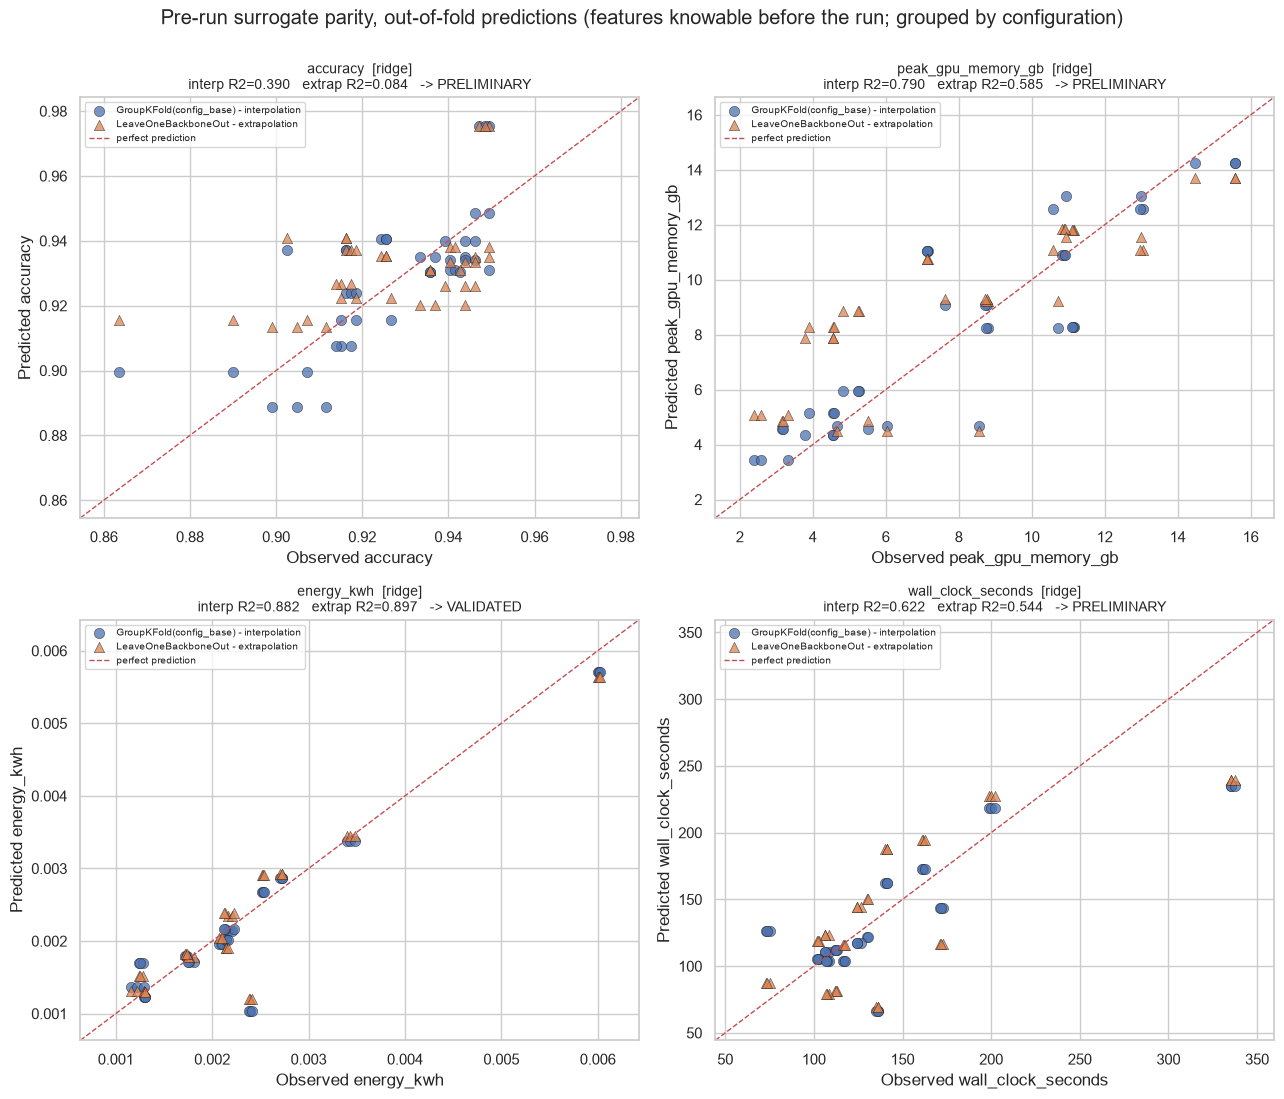

In [18]:
# Actual vs predicted, one panel per target, both protocols overlaid.
# Each panel uses the model selected for that target in the cell above, so the figure shows
# what would actually ship rather than a uniform choice that is wrong for some targets.
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
chosen = governing_status.set_index('target')

for ax, target in zip(axes.ravel(), TARGETS):
    model_name = chosen.loc[target, 'model']
    sub = oof_predictions[(oof_predictions['target'] == target)
                          & (oof_predictions['model'] == model_name)]

    for protocol, marker, label in [
        ('groupkfold_config_base', 'o', 'GroupKFold(config_base) - interpolation'),
        ('leave_one_backbone_out', '^', 'LeaveOneBackboneOut - extrapolation'),
    ]:
        s = sub[sub['protocol'] == protocol]
        ax.scatter(s['actual'], s['predicted'], marker=marker, alpha=0.75,
                   edgecolor='k', linewidth=0.4, s=55, label=label)

    lo = min(sub['actual'].min(), sub['predicted'].min())
    hi = max(sub['actual'].max(), sub['predicted'].max())
    pad = (hi - lo) * 0.08
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'r--', lw=1, label='perfect prediction')
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel(f'Observed {target}')
    ax.set_ylabel(f'Predicted {target}')

    r = chosen.loc[target]
    ax.set_title(f'{target}  [{model_name}]\n'
                 f'interp R2={r["interp_R2"]:.3f}   extrap R2={r["extrap_R2"]:.3f}   '
                 f'-> {r["governing_status"]}', fontsize=10)
    ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Pre-run surrogate parity, out-of-fold predictions '
             '(features knowable before the run; grouped by configuration)', y=0.998)
plt.tight_layout()
plt.show()

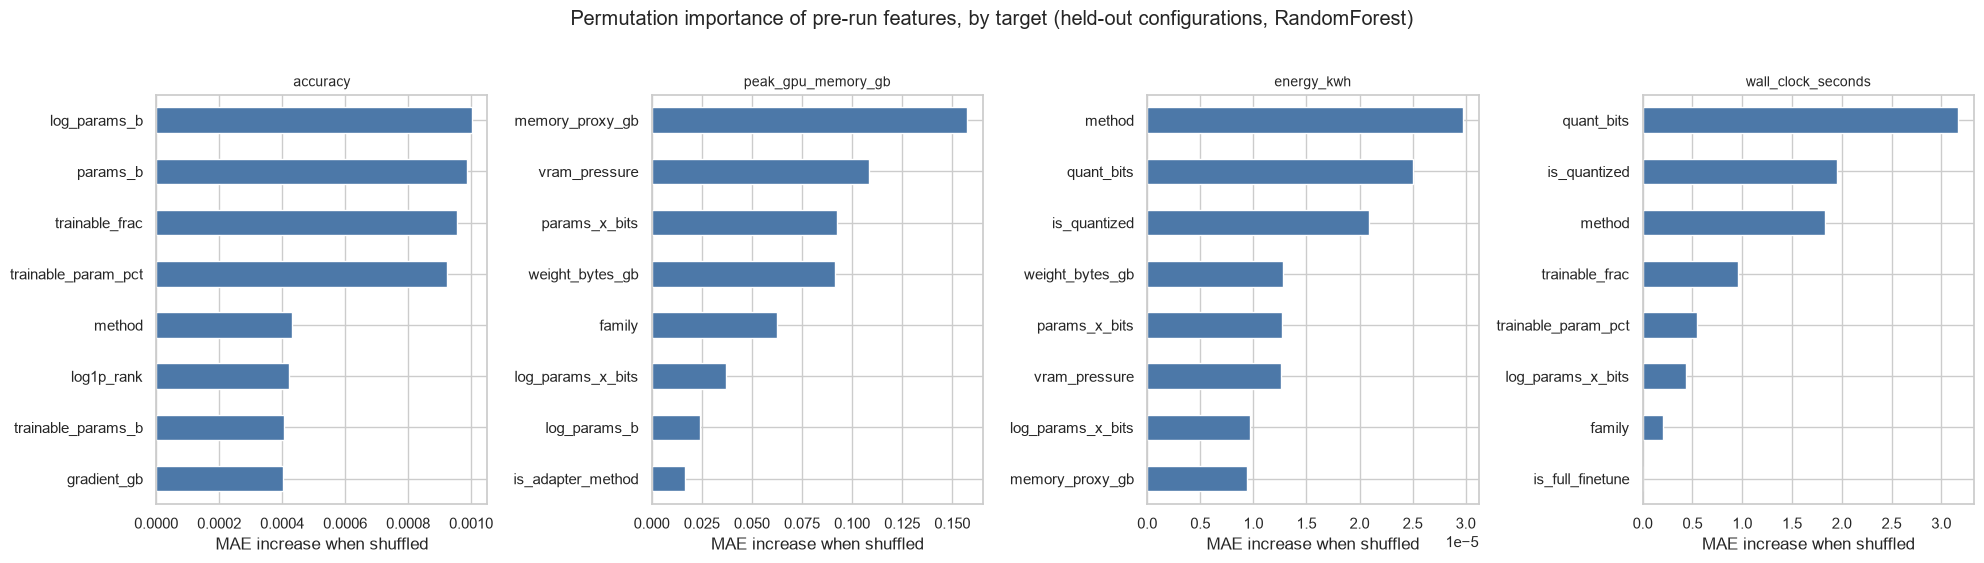

Several features are algebraic transforms of one another (params_b, log_params_b, params_x_bits, weight_bytes_gb...),
so importance is shared arbitrarily among them. Read these as feature-family signals, not independent contributions.


In [19]:
# Which pre-run features drive each cost target? Permutation importance on a
# held-out-configuration split, so the ranking reflects generalisation rather than fit.
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit

fig, axes = plt.subplots(1, len(TARGETS), figsize=(20, 5.5), sharex=False)

for ax, target in zip(axes, TARGETS):
    data = runs.dropna(subset=[target]).reset_index(drop=True)
    X, y = data[FEATURES], data[target]
    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
                  .split(X, y, data['config_base']))

    model = build_model('rf', target)
    model.fit(X.iloc[tr], y.iloc[tr])
    pi = permutation_importance(model, X.iloc[te], y.iloc[te],
                               n_repeats=30, random_state=RANDOM_STATE,
                               scoring='neg_mean_absolute_error')
    imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False).head(8)

    imp.iloc[::-1].plot(kind='barh', ax=ax, color='#4C78A8')
    ax.set_title(target, fontsize=10)
    ax.set_xlabel('MAE increase when shuffled')

fig.suptitle('Permutation importance of pre-run features, by target '
             '(held-out configurations, RandomForest)', y=1.02)
plt.tight_layout()
plt.show()

print('Several features are algebraic transforms of one another (params_b, log_params_b, '
      'params_x_bits, weight_bytes_gb...),\nso importance is shared arbitrarily among them. '
      'Read these as feature-family signals, not independent contributions.')

## 9. Summary & Next Steps

In [20]:
print('DATASET SUMMARY')
print('=' * 72)
print(f'Total rows in file                      : {len(df)}')
print(f'  surrogate_train (raw measurement rows): {len(peft_runs)}')
print(f'  -> canonical configurations           : {len(runs)}'
      f'   ({runs["config_base"].nunique()} configs x up to 3 seeds)')
print(f'  scale_reference (inference only)      : {len(scale_ref)}')
print(f'  context_only (pretraining)            : {len(context)}')
print()
print(f'Methods                                 : {runs["method"].nunique()} '
      f'({", ".join(sorted(runs["method"].unique()))})')
print(f'Backbones                               : {runs["backbone"].nunique()} '
      f'({", ".join(sorted(runs["backbone"].unique()))})')
print(f'Families                                : {", ".join(sorted(runs["family"].unique()))}')
print(f'Parameter range (B)                     : '
      f'{runs["params_b"].min()} - {runs["params_b"].max()}')
print(f'GPU budget (GB)                         : {runs["gpu_total_gb"].unique()[0]}')
print()
print('Outcome ranges across canonical configurations:')
for col, fmt in [('accuracy', '.4f'), ('peak_gpu_memory_gb', '.3f'),
                 ('energy_kwh', '.6f'), ('wall_clock_seconds', '.2f'),
                 ('carbon_kgco2eq', '.6f')]:
    lo, hi = runs[col].min(), runs[col].max()
    print(f'  {col:22s}: {lo:{fmt}} - {hi:{fmt}}')
print()
print('Surrogate status (governing, weaker protocol):')
for _, r in governing_status.iterrows():
    print(f'  {r["target"]:22s}: {r["governing_status"]:12s} '
          f'(interp R2={r["interp_R2"]:+.3f}, extrap R2={r["extrap_R2"]:+.3f})')
print(f'  {"OVERALL":22s}: {overall}')
print()
print('Energy figures use the valid telemetry pass only; carbon is derived as '
      'energy_kwh * 0.65, not measured.')

DATASET SUMMARY
Total rows in file                      : 477
  surrogate_train (raw measurement rows): 82
  -> canonical configurations           : 41   (14 configs x up to 3 seeds)
  scale_reference (inference only)      : 369
  context_only (pretraining)            : 26

Methods                                 : 5 (full_ft, lisa, lora, lora_fa, qlora)
Backbones                               : 4 (large, medium, small, tiny)
Families                                : llama, qwen
Parameter range (B)                     : 0.5 - 3.0
GPU budget (GB)                         : 15.6

Outcome ranges across canonical configurations:
  accuracy              : 0.8635 - 0.9495
  peak_gpu_memory_gb    : 2.387 - 15.584
  energy_kwh            : 0.001158 - 0.006028
  wall_clock_seconds    : 72.78 - 337.81
  carbon_kgco2eq        : 0.000753 - 0.003918

Surrogate status (governing, weaker protocol):
  accuracy              : PRELIMINARY  (interp R2=+0.390, extrap R2=+0.084)
  peak_gpu_memory_gb    : PR

### Suggested next steps

1. **Validated energy re-measurement** — exactly one telemetry pass per configuration is trustworthy, so
   energy currently has no replication at all. A second *valid* pass (NVML under load, verified against a
   wall-plug reading) would turn every energy figure here from a point estimate into one with an error bar.
   This is the highest-value missing experiment in the project.
2. **Break the scale/method confound** — `full_ft` exists only at 0.5B and `qlora` is the only method that
   fits at 3.0B, so no method comparison is like-for-like across the full range. Any additional run should
   fill a cell of the method x backbone matrix rather than add seeds to a cell that already has three.
3. **Mixed-effects modelling** — treat `config_base` as a random effect to estimate method-level effects while
   controlling for backbone and family, instead of comparing marginal means across unequal coverage.
4. **Uncertainty quantification** — with 3 seeds per configuration, report 95% intervals and explicitly flag
   statistically indistinguishable method pairs. Accuracy spans ~0.09 across the whole benchmark, so most
   pairwise gaps are inside seed noise.
5. **Carbon accounting** — the fixed 0.65 kgCO2eq/kWh factor is a project assumption. Re-derive per region
   and report carbon as a range over grid intensities rather than a single number.
6. **Extrapolation honesty in the recommender** — leave-one-backbone-out performance is the bound that applies
   when the CLI scores a backbone outside the four measured tiers. Surface that as a per-candidate confidence
   rather than emitting a bare point estimate.
7. **Cross-dataset validation** — merge with GARF, EfficientLLM, or PEFT-Bench results to test whether the
   observed efficiency patterns hold beyond a single T4 and a single SST-2 task.

Remember to cite the dataset (DOI `10.34740/KAGGLE/DSV/20178095`) in any publication derived from this notebook.